# Observed rate vs separation (single curve)

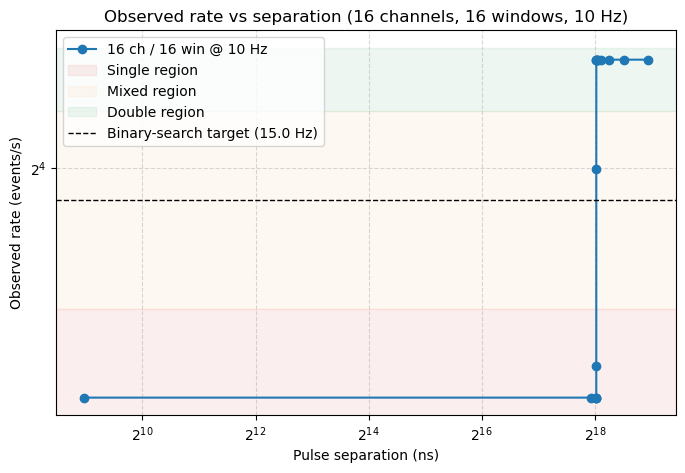

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve().parent
sys.path.append(str(ROOT / 'src'))
from deadtime_analysis import DeadtimeAnalysis
from deadtime_analysis.plotting import apply_rate_guides

DATA_FILES = [
    ROOT / 'data' / 'double_pulse_deadtime-11-20-25.jsonl',
    ROOT / 'data' / 'double_pulse_deadtime-11-22-25.jsonl',
]
PULSE_RATE = 10.0
CHANNELS = 16
WINDOWS = 16

analysis = DeadtimeAnalysis.from_jsonl([str(p) for p in DATA_FILES])
df = analysis.subset(PULSE_RATE)
subset = df[(df['channel_count'] == CHANNELS) & (df['windows'] == WINDOWS)]
if subset.empty:
    raise ValueError('No data for the specified channel/window configuration')
subset = subset.sort_values('separation_ns')
thresholds = analysis._thresholds_for_rate(PULSE_RATE)

fig, ax = plt.subplots(figsize=(8,5))
ax.plot(subset['separation_ns'], subset['observed_rate_hz'], marker='o', label=f'{CHANNELS} ch / {WINDOWS} win @ {PULSE_RATE:.0f} Hz')
apply_rate_guides(ax, thresholds)
ax.set_xscale('log', base=2)
ax.set_yscale('log', base=2)
ax.set_xlabel('Pulse separation (ns)')
ax.set_ylabel('Observed rate (events/s)')
ax.set_title('Observed rate vs separation (16 channels, 16 windows, 10 Hz)')
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend()
plt.show()